In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from _src import MLP

In [5]:
# データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    x1 = np.linspace(0, 2 * np.pi, int(np.sqrt(n)))
    x2 = np.linspace(0, 2 * np.pi, int(np.sqrt(n)))
    x1_grid, x2_grid = np.meshgrid(x1, x2)
    X = np.vstack((x1_grid.flatten(), x2_grid.flatten())).T
    y_true = np.sin(2 * X[:, 0]) * np.cos(2 * X[:, 1])
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# 予測結果のプロット
def plot_3d_surface(X, y, predict_func, title, outlier_indices, y_true):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X[:, 0], X[:, 1], y_true, color='blue', label='True Data')
    ax.scatter(X[outlier_indices, 0], X[outlier_indices, 1], y[outlier_indices], color='red', label='Outliers', s=50)

    x1_grid, x2_grid = np.meshgrid(np.linspace(0, 2 * np.pi, 100), np.linspace(0, 2 * np.pi, 100))
    X_grid = np.vstack((x1_grid.flatten(), x2_grid.flatten())).T
    y_grid_pred = predict_func(X_grid).reshape(x1_grid.shape)

    ax.plot_surface(x1_grid, x2_grid, y_grid_pred, cmap='viridis', alpha=0.6)

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')
    ax.set_title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None):
    model = MLP(input_dim=2, hidden_dim=100, output_dim=1)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=5000)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=5000)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_3d_surface(X, y, predict_func, title, outlier_indices, y_true)

In [6]:
X, y, y_true, outlier_indices = generate_data()

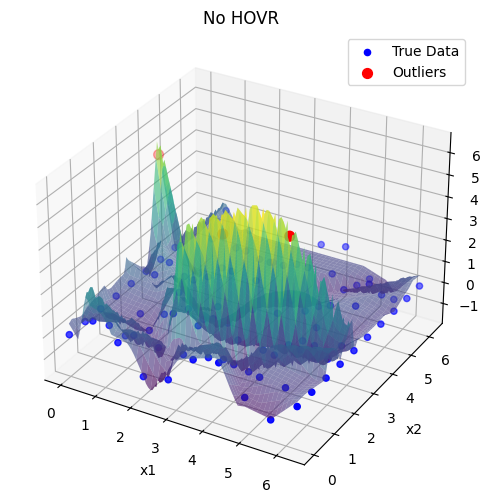

In [10]:
# 通常のモデル (HOVRなし)
train_and_plot(X, y, y_true, outlier_indices)

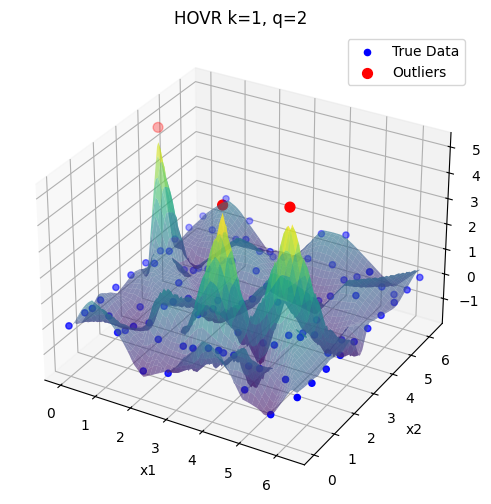

In [11]:
# (1, 2)-VR
train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 1, 2))

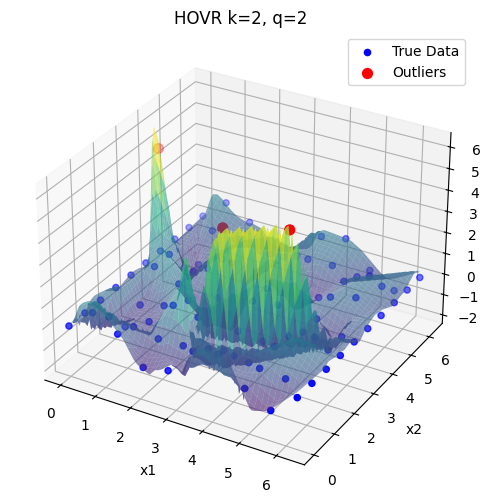

In [12]:
# (2, 2)-VR
train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 2, 2))

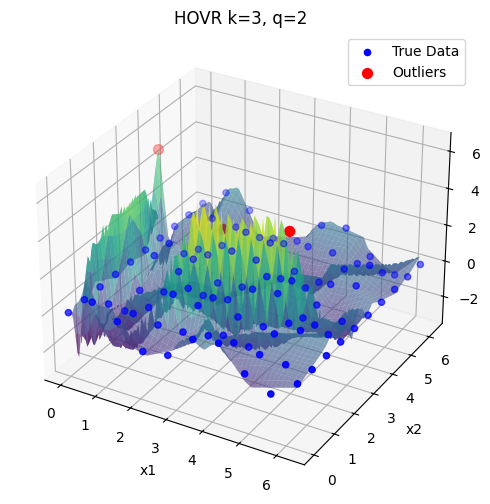

In [13]:
# (3, 2)-VR
train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 3, 2))

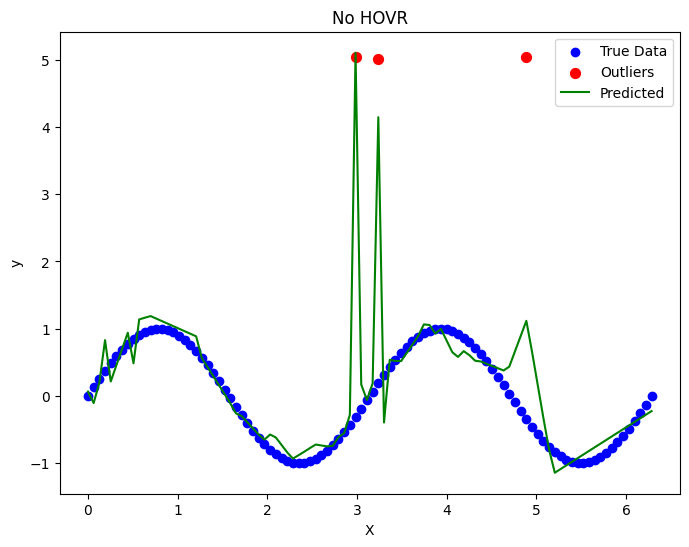

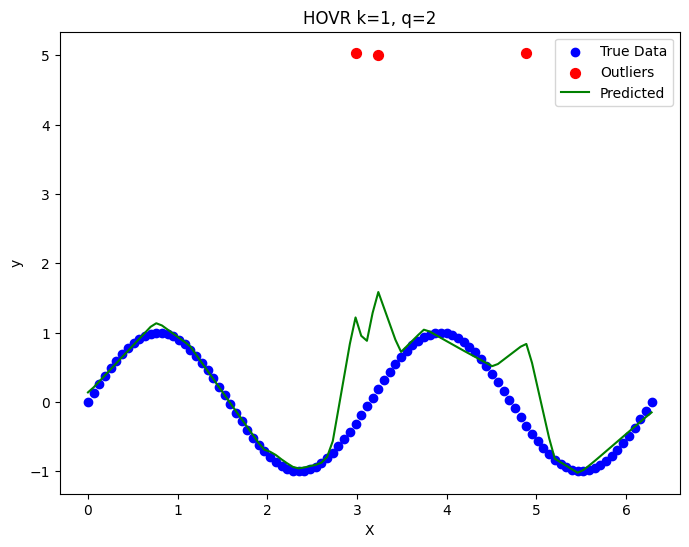

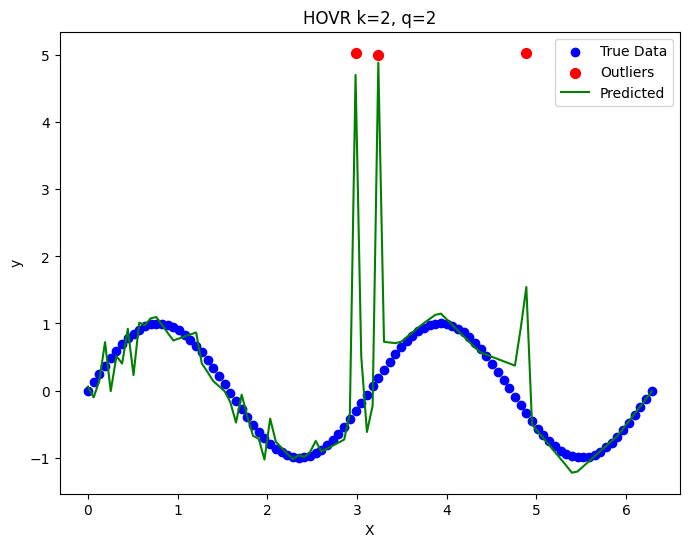

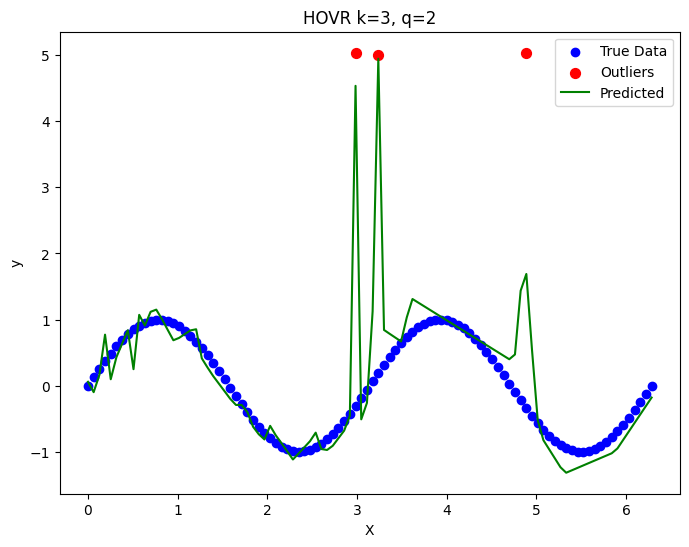

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1次元データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    X = np.linspace(0, 2 * np.pi, n).reshape(-1, 1)
    y_true = np.sin(2 * X).flatten()
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# 1次元データの予測結果をプロット
def plot_1d(X, y, predict_func, title, outlier_indices, y_true):
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y_true, color='blue', label='True Data')
    plt.scatter(X[outlier_indices], y[outlier_indices], color='red', label='Outliers', s=50)

    X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
    y_grid_pred = predict_func(X_grid)

    plt.plot(X_grid, y_grid_pred, color='green', label='Predicted')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None):
    model = MLP(input_dim=1, hidden_dim=64, output_dim=1)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=5000)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=5000)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_1d(X, y, predict_func, title, outlier_indices, y_true)

# 使用例
if __name__ == "__main__":
    X, y, y_true, outlier_indices = generate_data()

    # 通常のモデル (HOVRなし)
    train_and_plot(X, y, y_true, outlier_indices)

    # (1, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 1, 2))

    # (2, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 2, 2))

    # (3, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 3, 2))


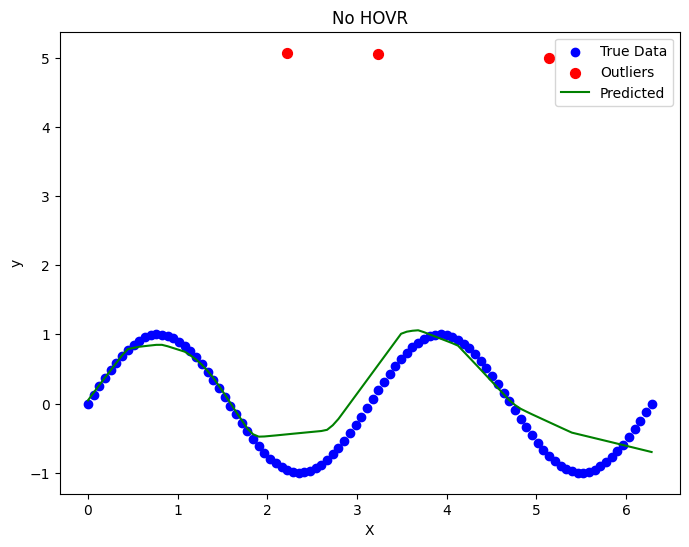

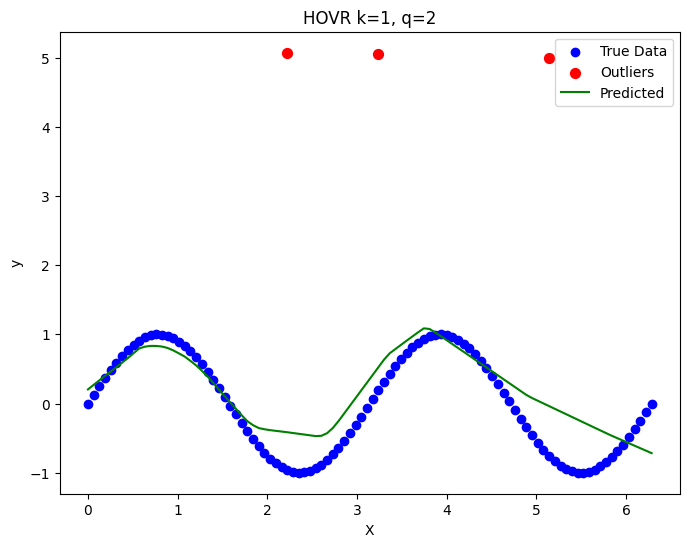

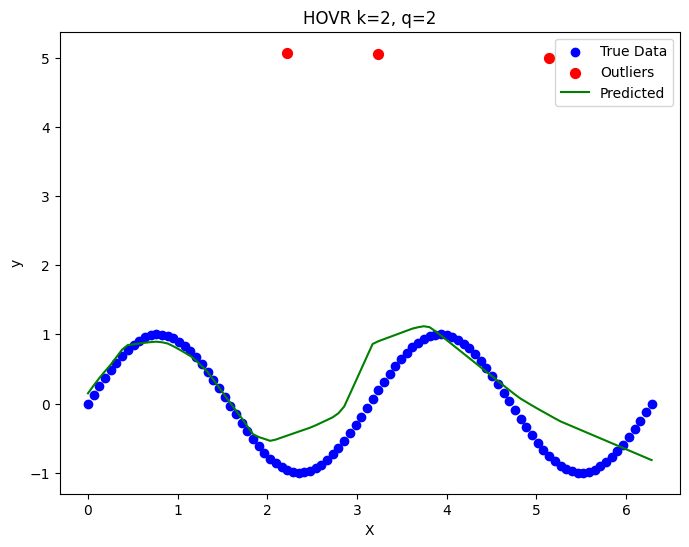

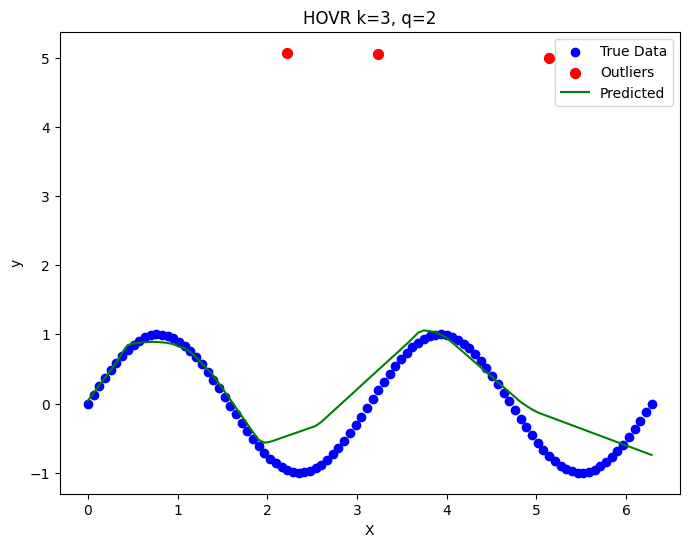

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1次元データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    X = np.linspace(0, 2 * np.pi, n).reshape(-1, 1)
    y_true = np.sin(2 * X).flatten()
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# 1次元データの予測結果をプロット
def plot_1d(X, y, predict_func, title, outlier_indices, y_true):
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y_true, color='blue', label='True Data')
    plt.scatter(X[outlier_indices], y[outlier_indices], color='red', label='Outliers', s=50)

    X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
    y_grid_pred = predict_func(X_grid)

    plt.plot(X_grid, y_grid_pred, color='green', label='Predicted')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None):
    model = MLP(input_dim=1, hidden_dim=64, output_dim=1)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=100)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=100)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_1d(X, y, predict_func, title, outlier_indices, y_true)

# 使用例
if __name__ == "__main__":
    X, y, y_true, outlier_indices = generate_data()

    # 通常のモデル (HOVRなし)
    train_and_plot(X, y, y_true, outlier_indices)

    # (1, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 1, 2))

    # (2, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 2, 2))

    # (3, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 3, 2))


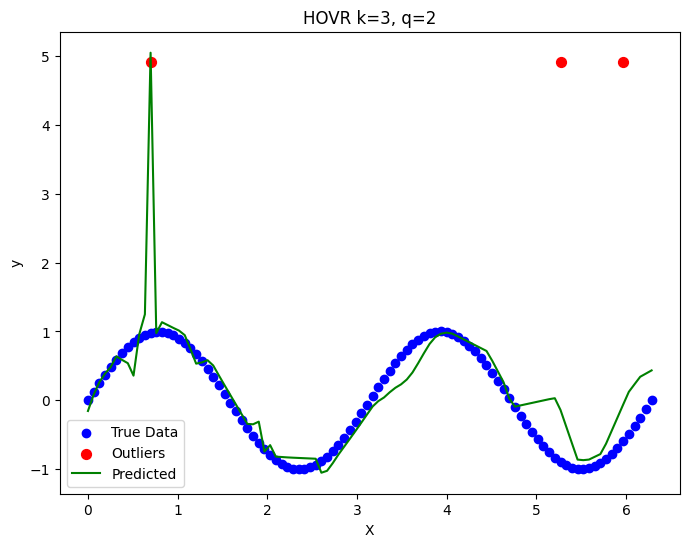

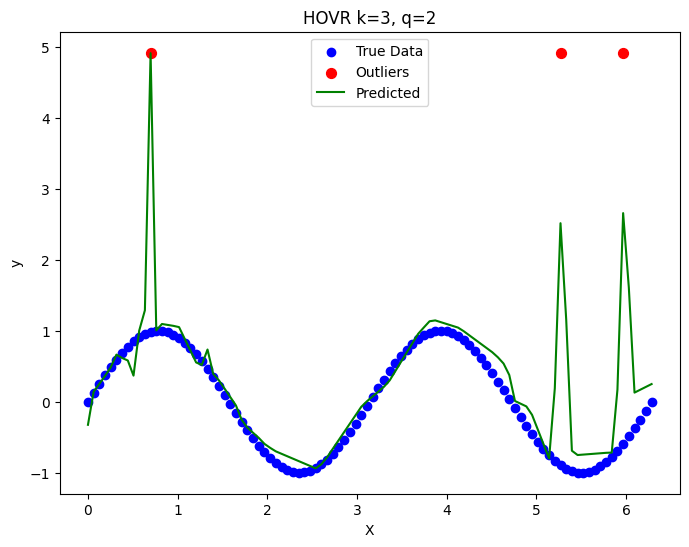

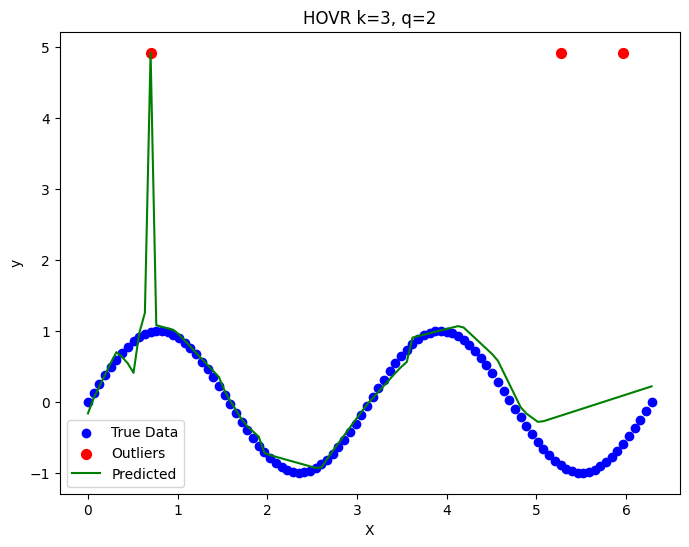

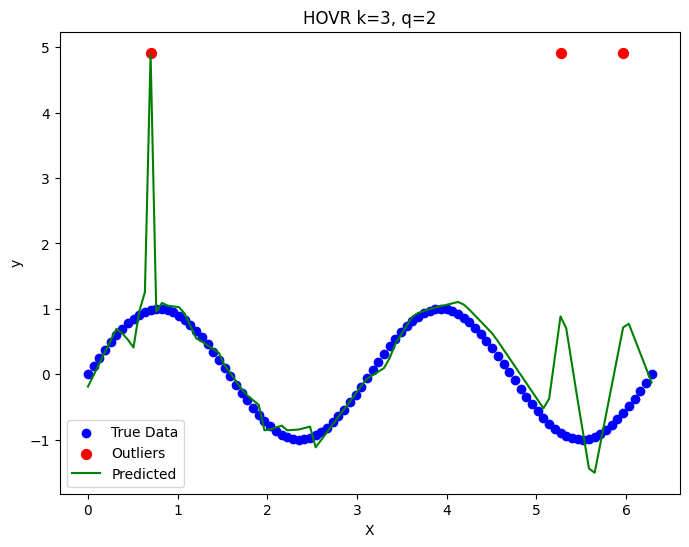

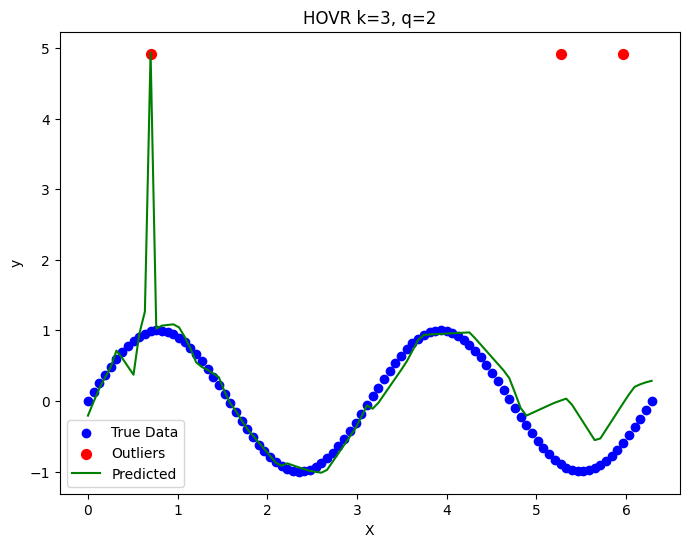

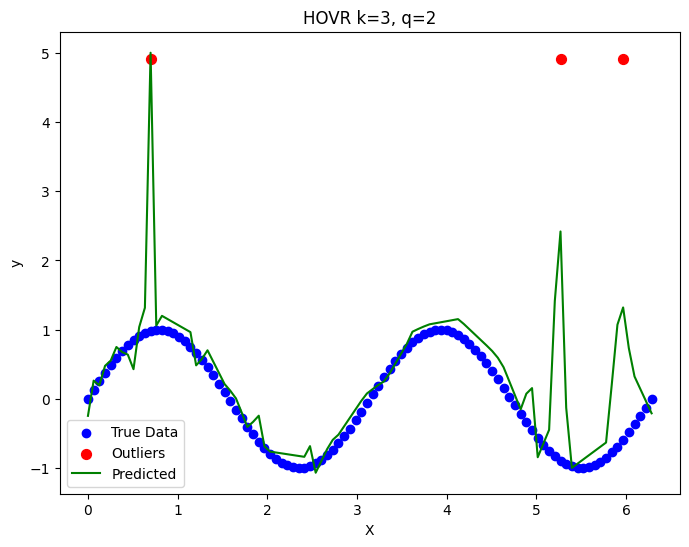

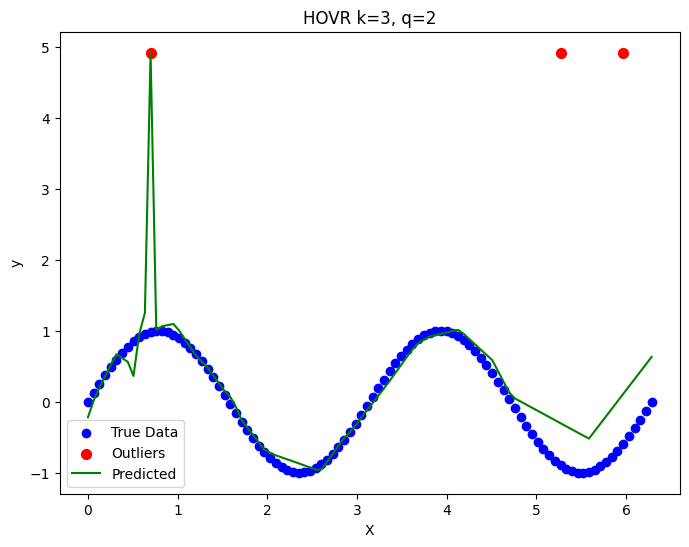

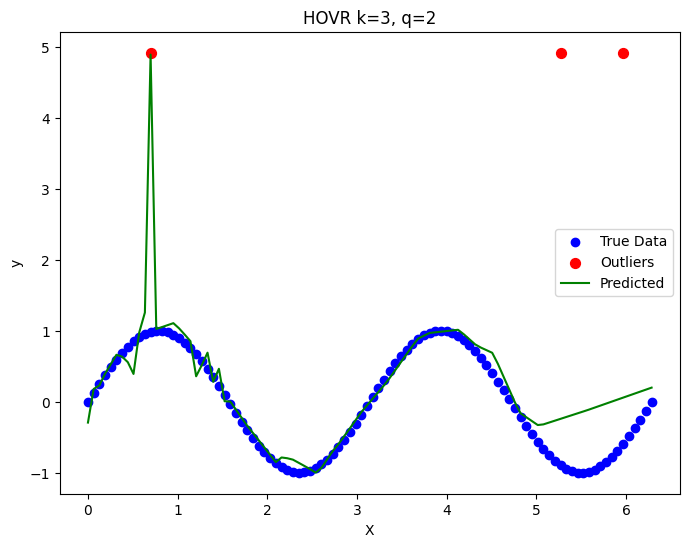

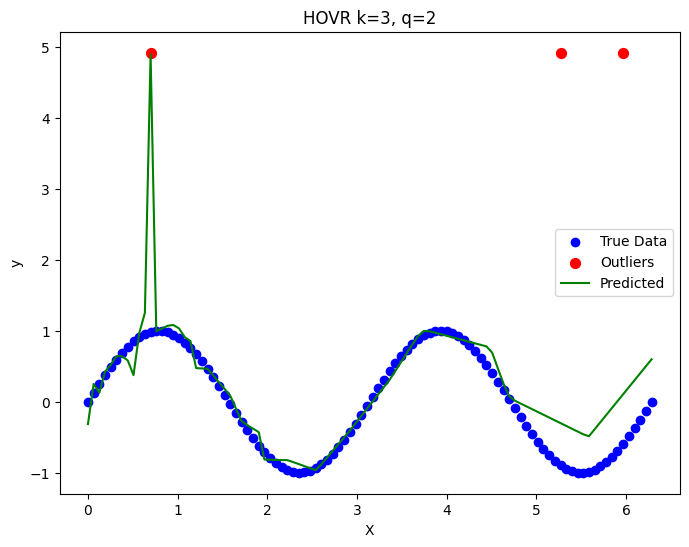

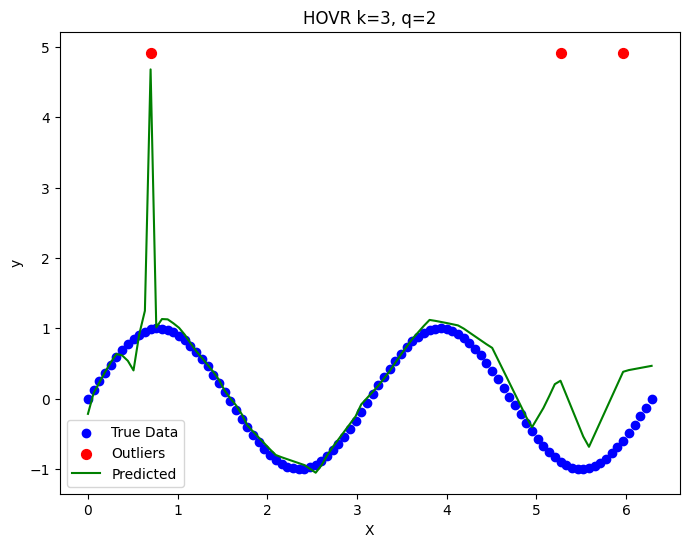

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1次元データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    X = np.linspace(0, 2 * np.pi, n).reshape(-1, 1)
    y_true = np.sin(2 * X).flatten()
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# 1次元データの予測結果をプロット
def plot_1d(X, y, predict_func, title, outlier_indices, y_true):
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y_true, color='blue', label='True Data')
    plt.scatter(X[outlier_indices], y[outlier_indices], color='red', label='Outliers', s=50)

    X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
    y_grid_pred = predict_func(X_grid)

    plt.plot(X_grid, y_grid_pred, color='green', label='Predicted')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None):
    model = MLP(input_dim=1, hidden_dim=64, output_dim=1)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=5000)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=5000)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_1d(X, y, predict_func, title, outlier_indices, y_true)

# 使用例
if __name__ == "__main__":
    X, y, y_true, outlier_indices = generate_data()

    for i in range(10):
        # (3, 2)-VR
        train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3 * (i+1), 3, 2))

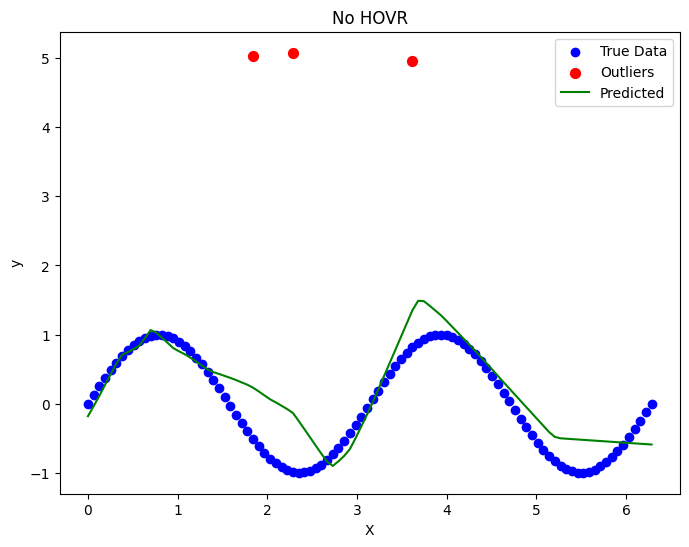

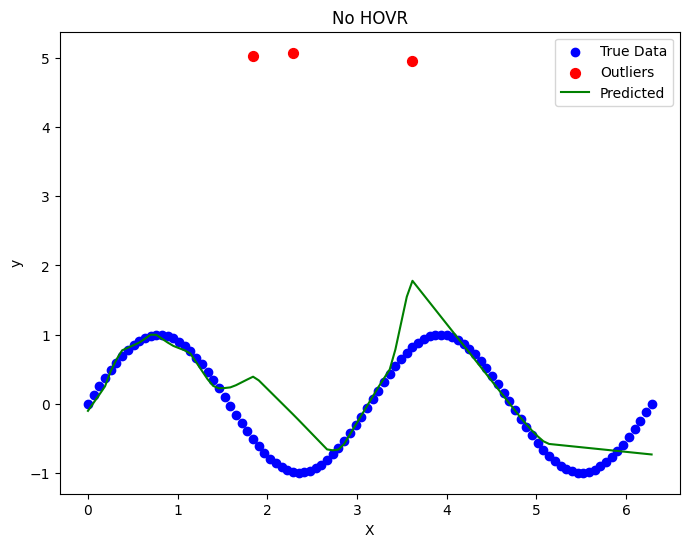

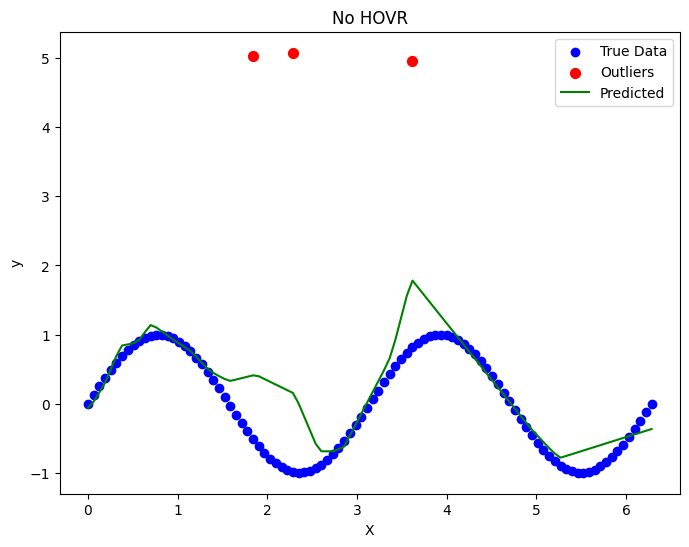

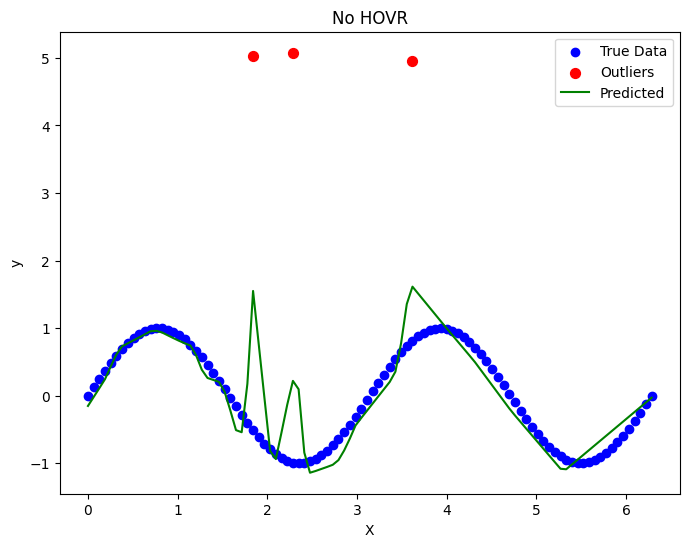

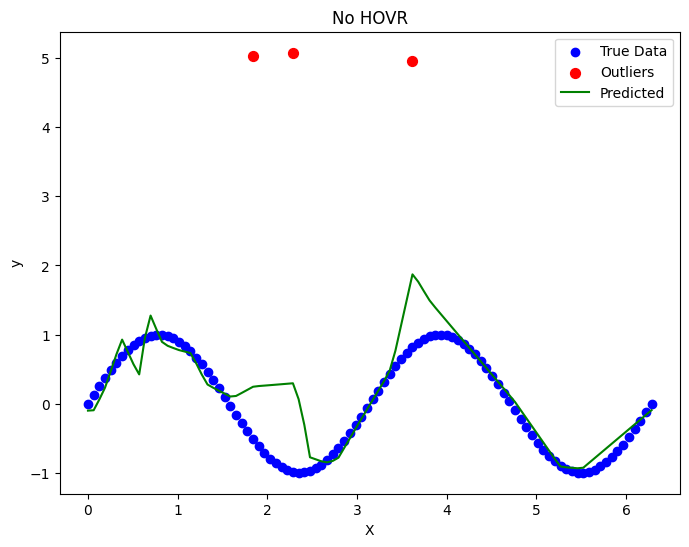

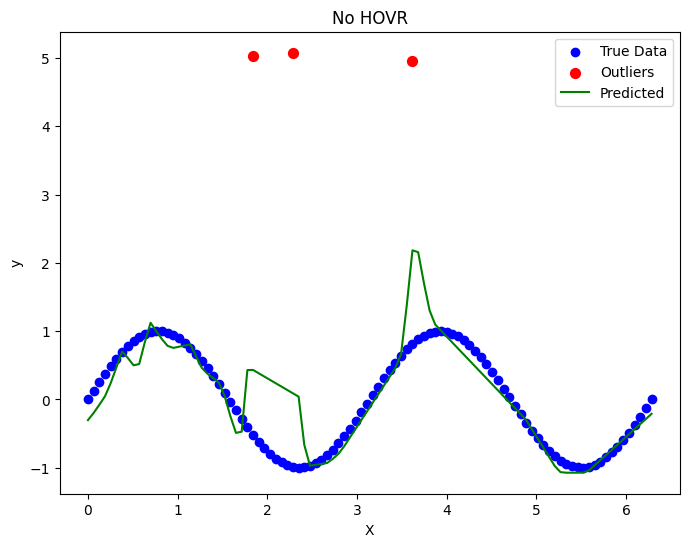

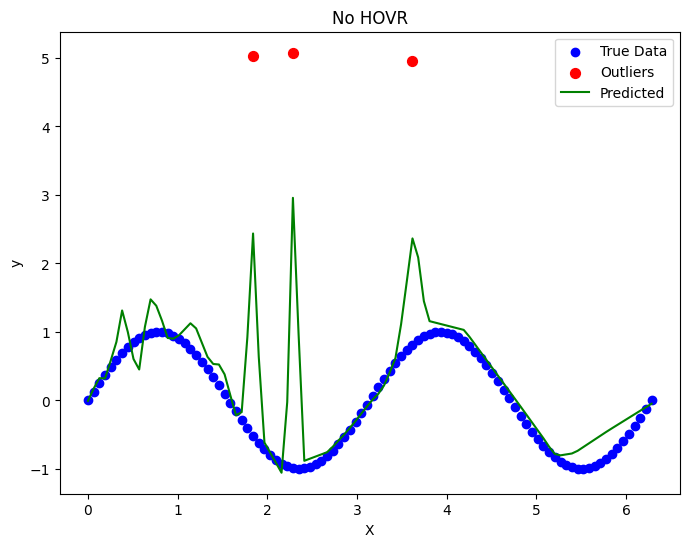

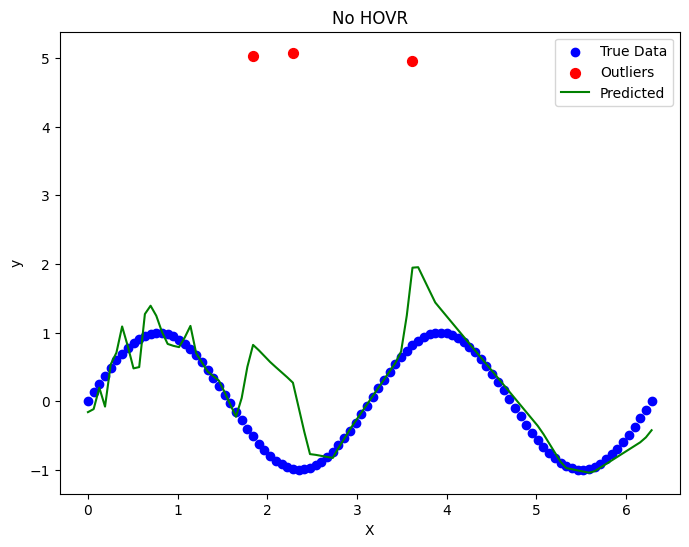

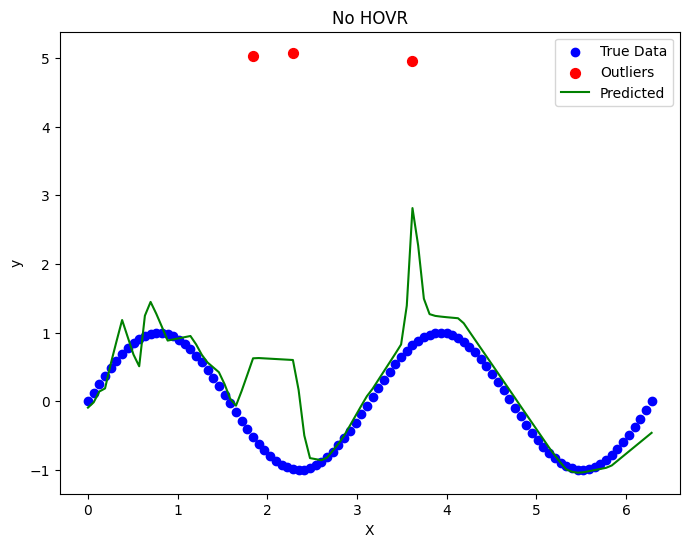

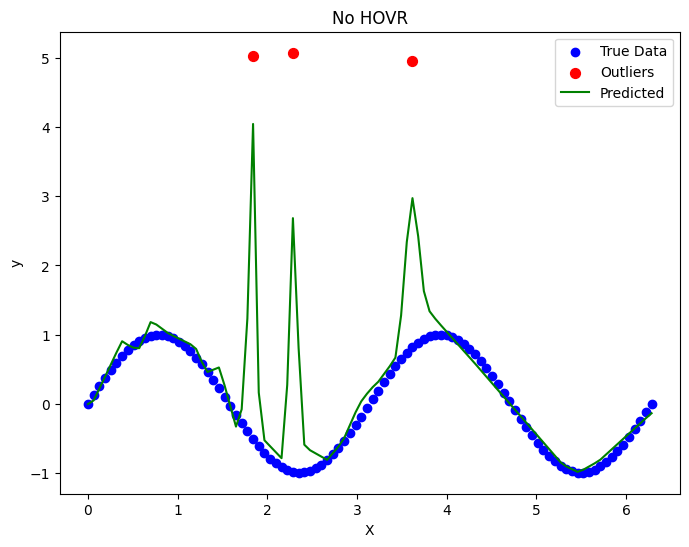

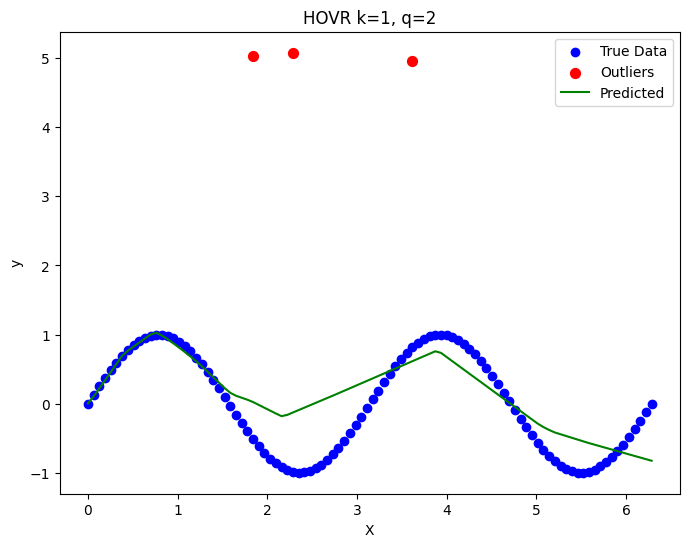

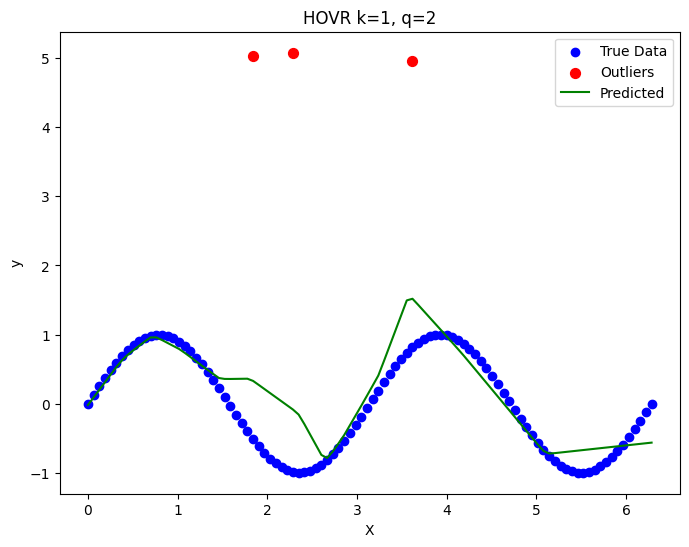

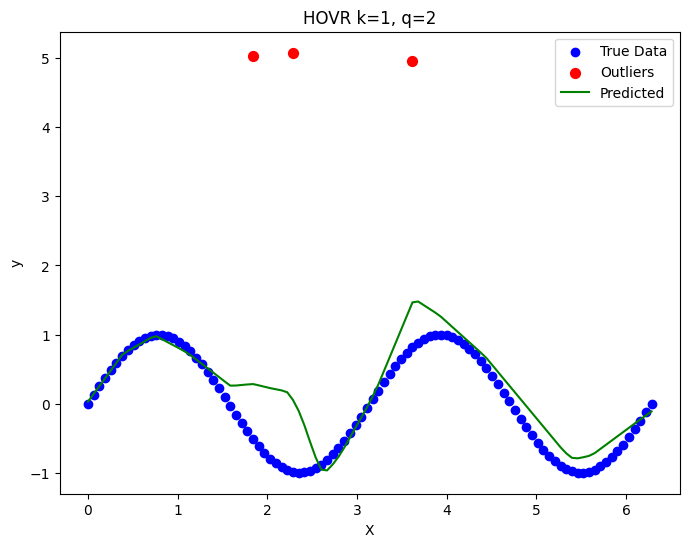

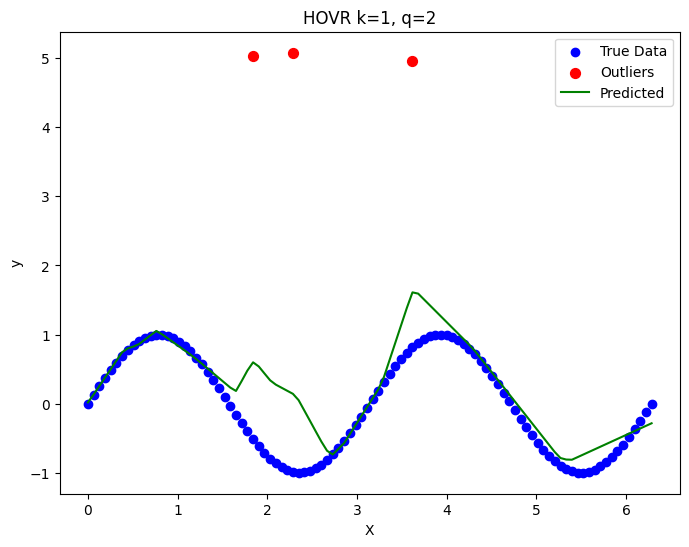

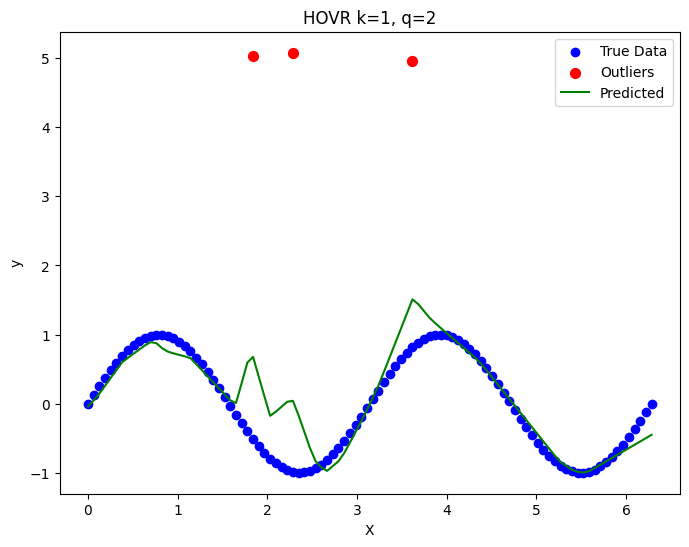

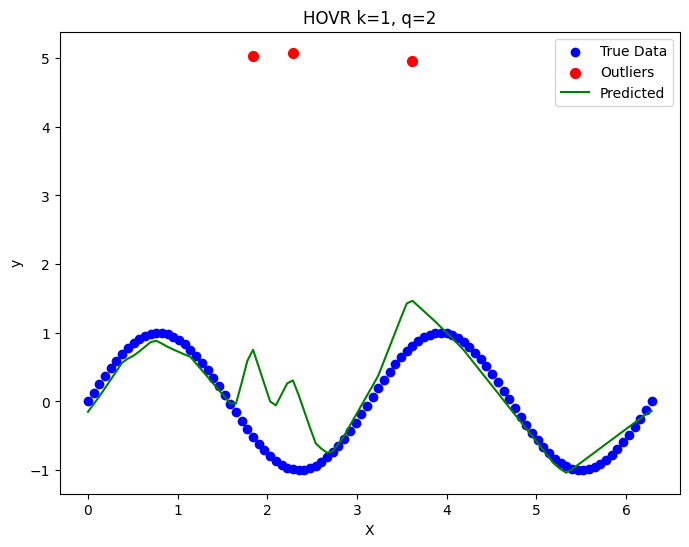

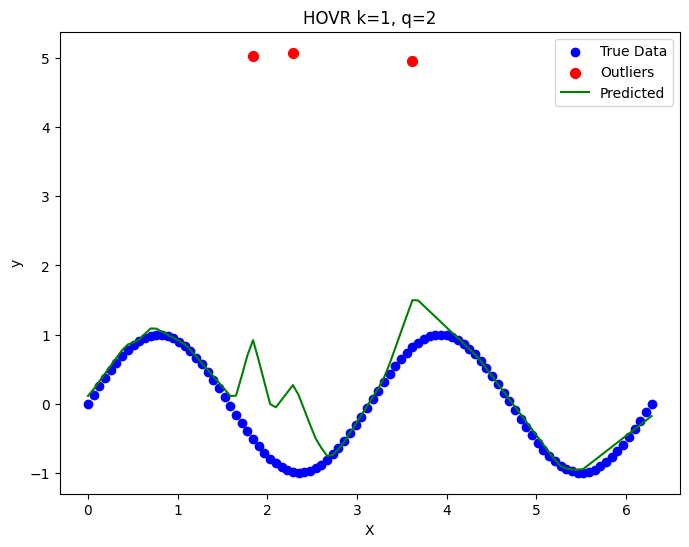

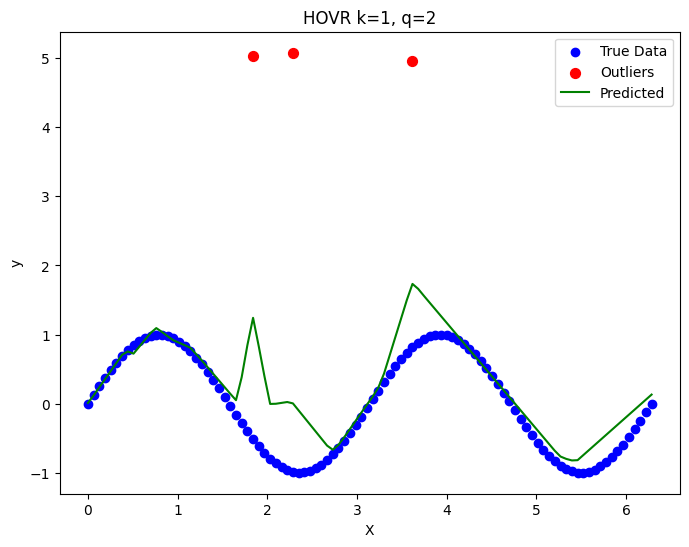

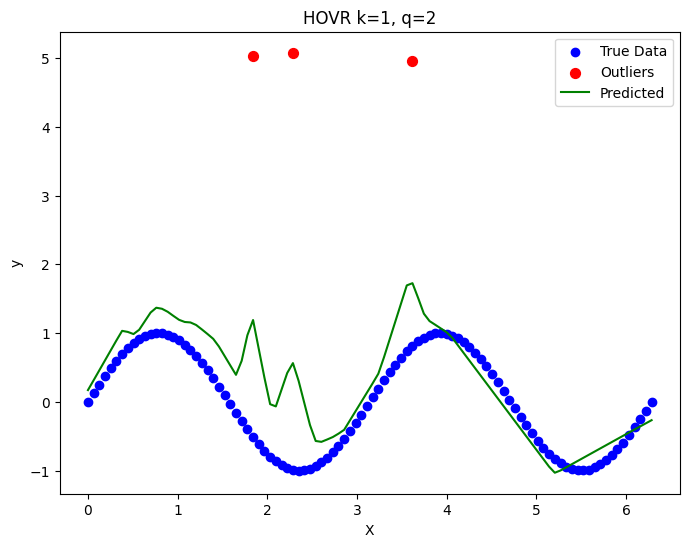

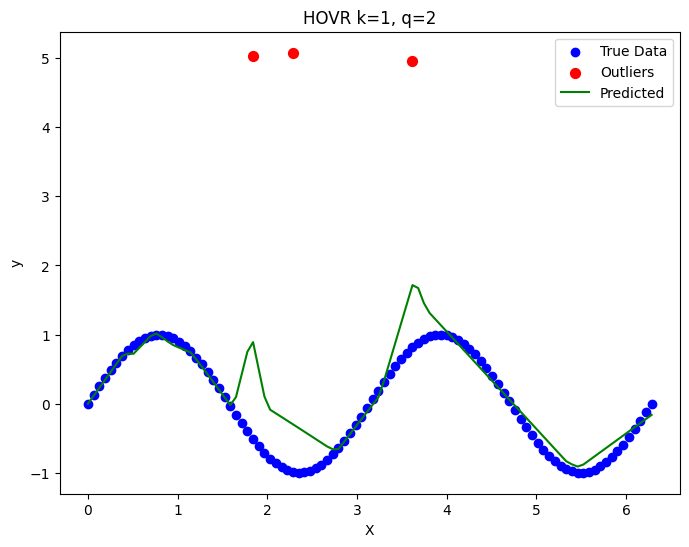

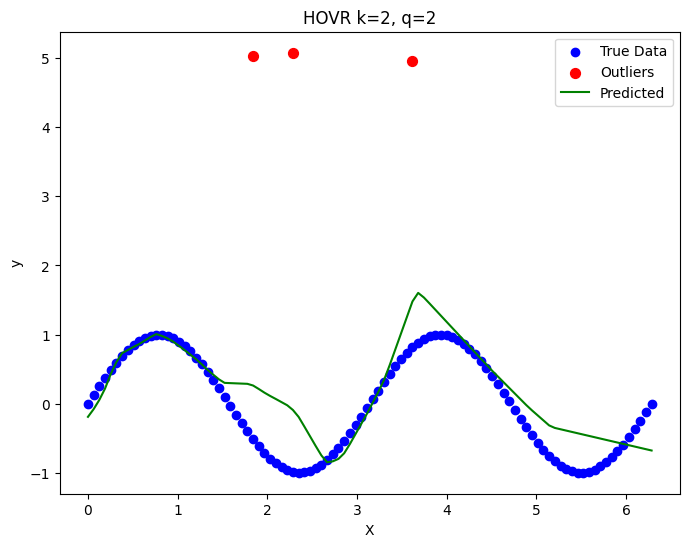

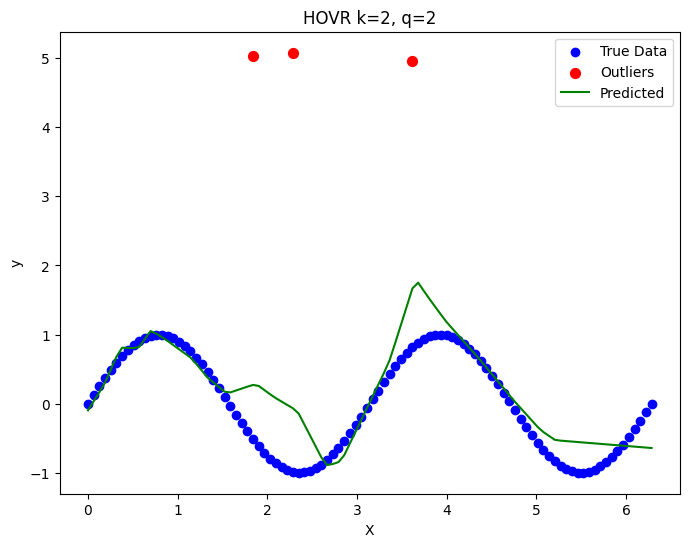

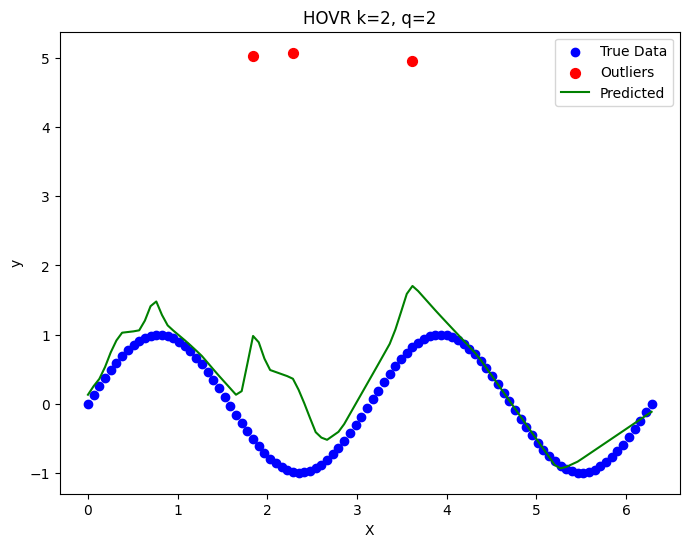

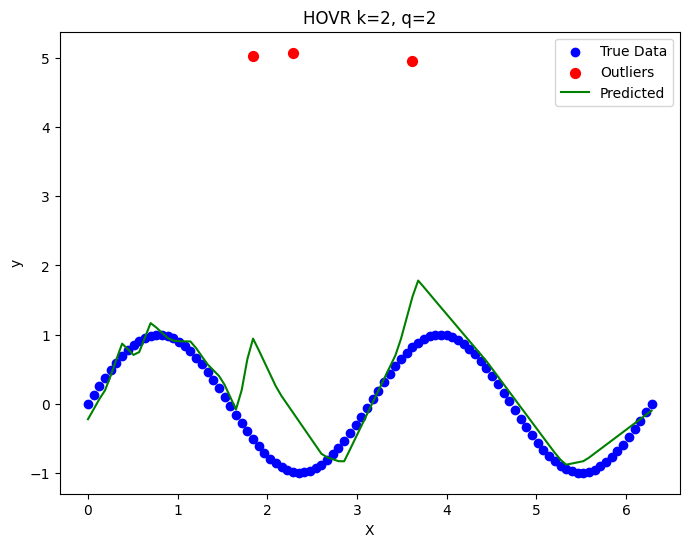

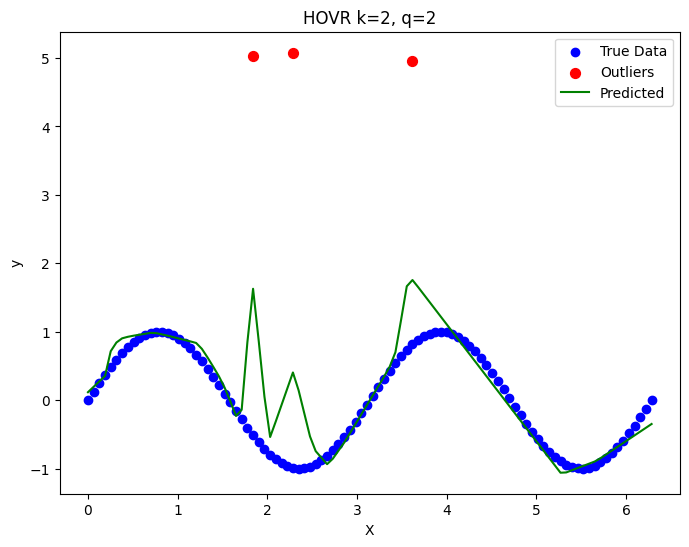

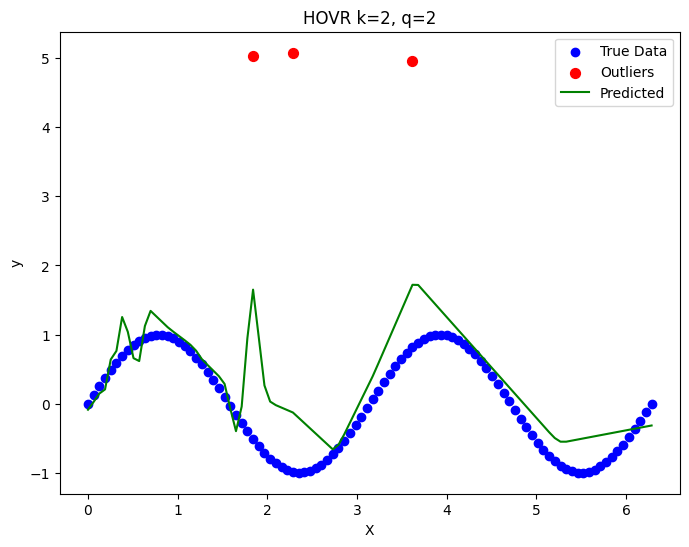

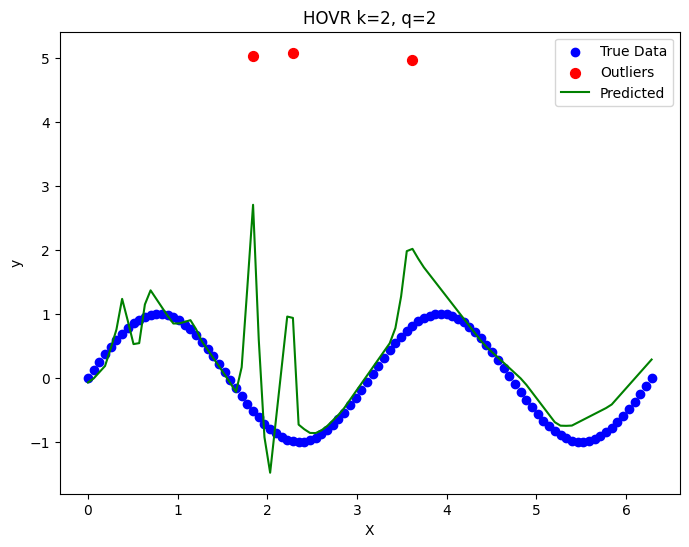

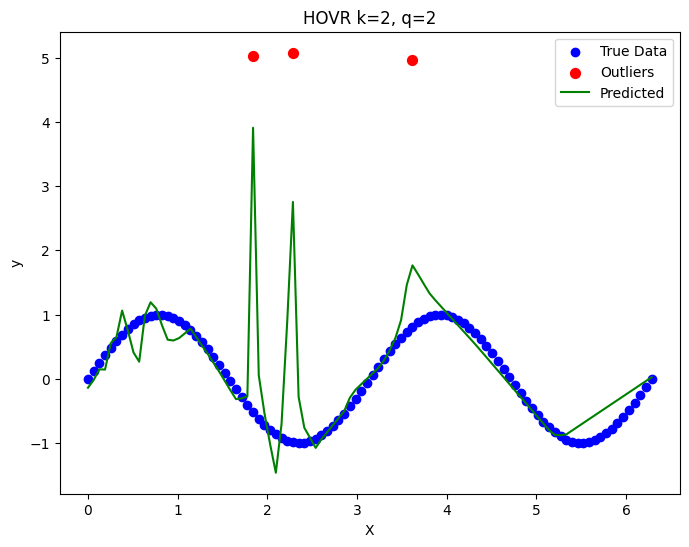

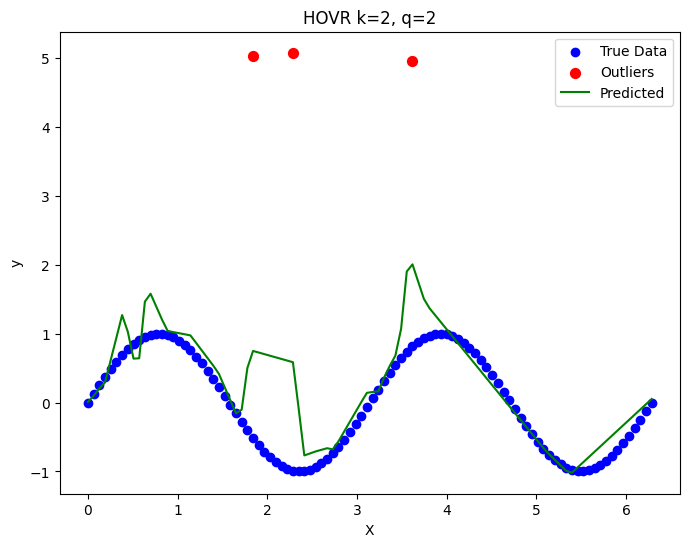

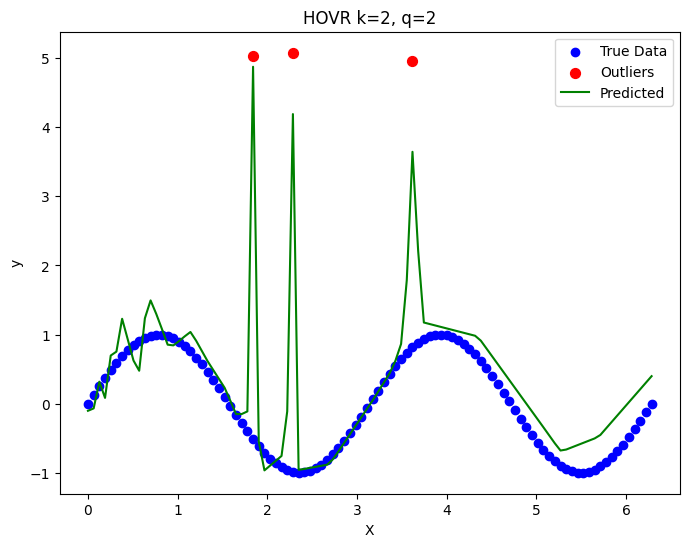

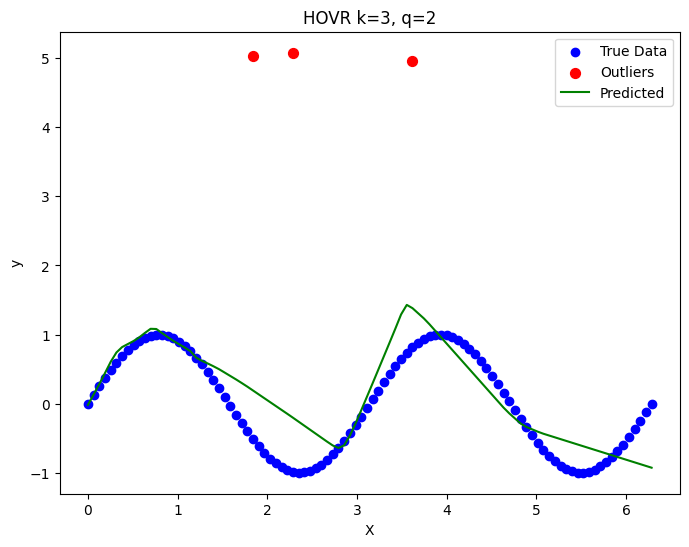

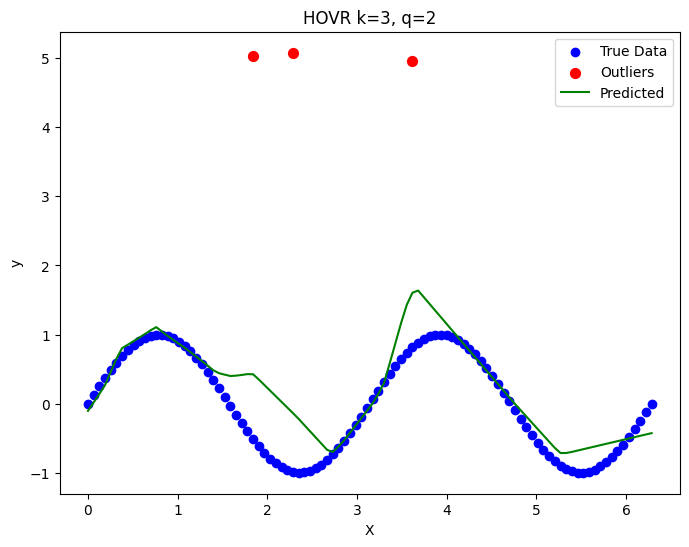

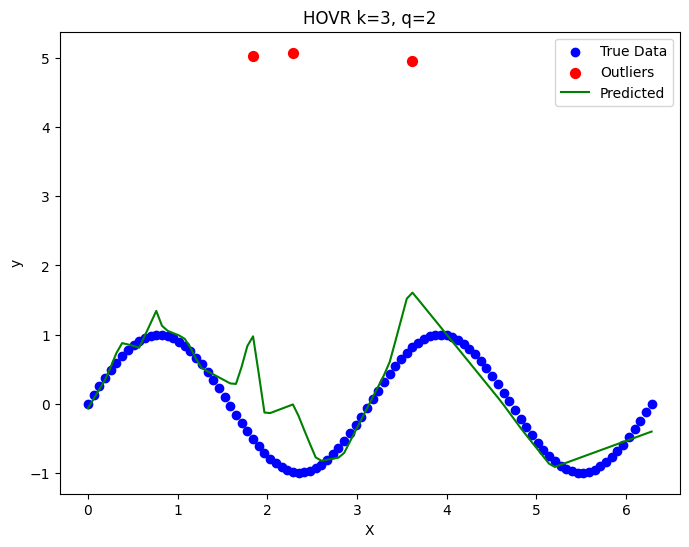

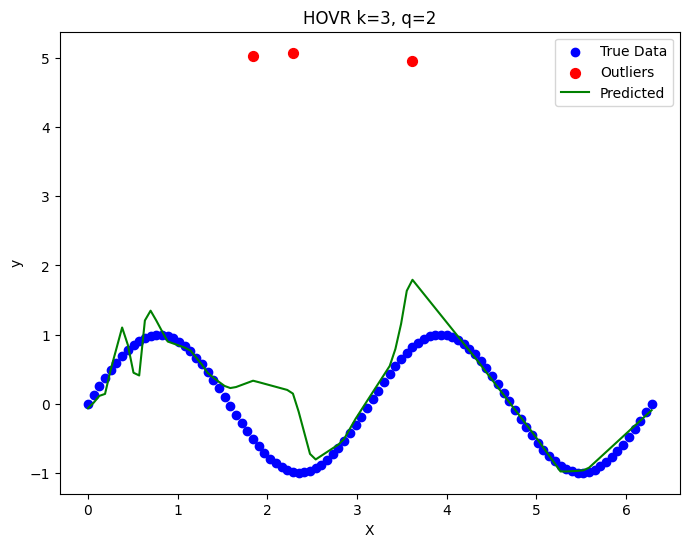

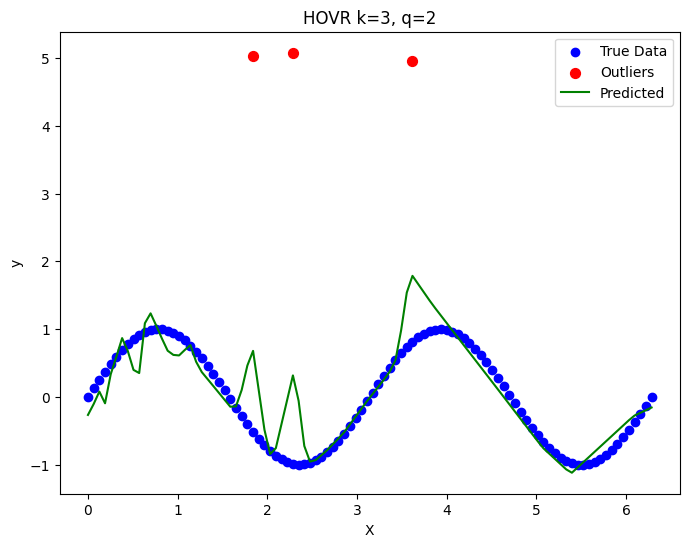

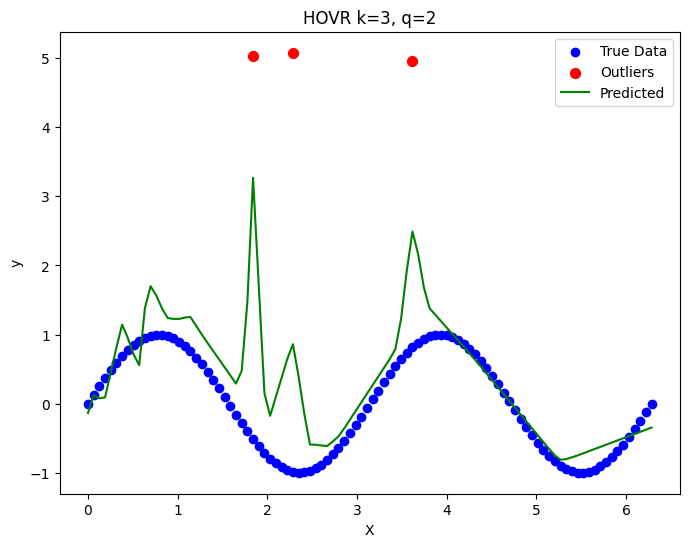

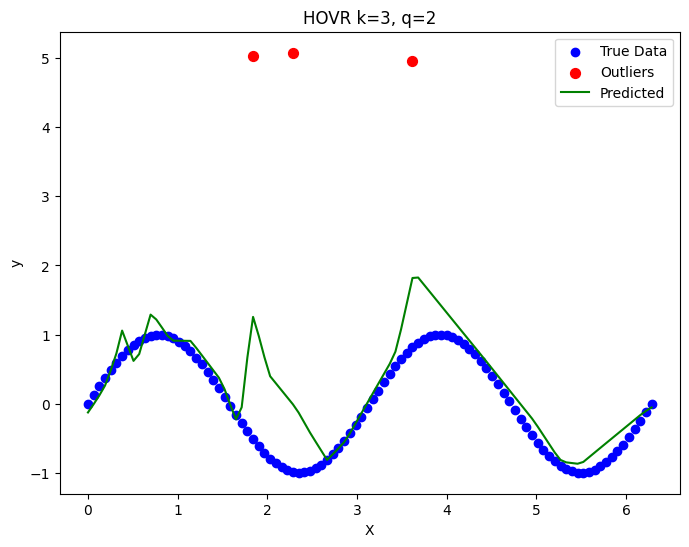

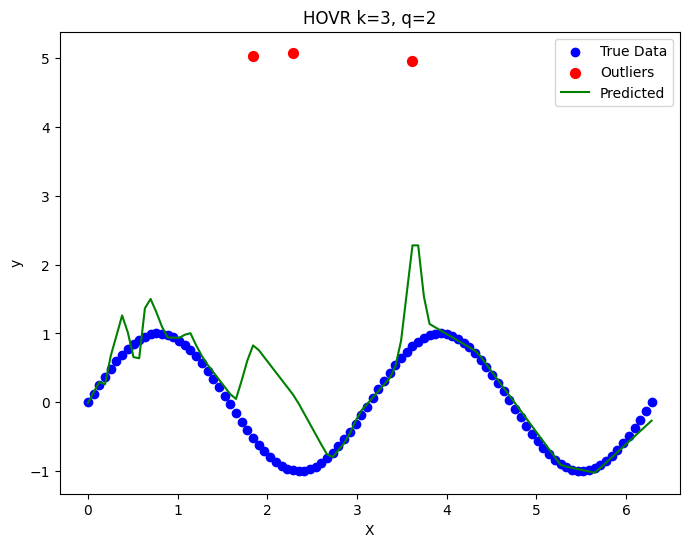

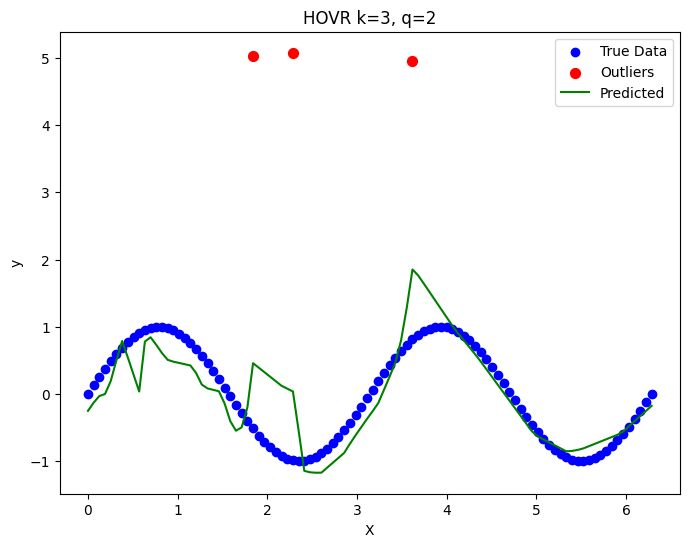

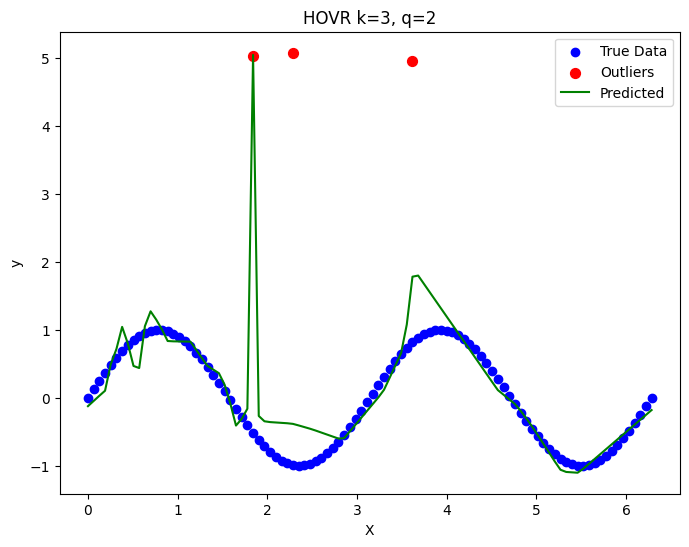

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1次元データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    X = np.linspace(0, 2 * np.pi, n).reshape(-1, 1)
    y_true = np.sin(2 * X).flatten()
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# 1次元データの予測結果をプロット
def plot_1d(X, y, predict_func, title, outlier_indices, y_true):
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y_true, color='blue', label='True Data')
    plt.scatter(X[outlier_indices], y[outlier_indices], color='red', label='Outliers', s=50)

    X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
    y_grid_pred = predict_func(X_grid)

    plt.plot(X_grid, y_grid_pred, color='green', label='Predicted')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None, num_epochs=100):
    model = MLP(input_dim=1, hidden_dim=64, output_dim=1)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=num_epochs)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=num_epochs)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_1d(X, y, predict_func, title, outlier_indices, y_true)

# 使用例
if __name__ == "__main__":
    X, y, y_true, outlier_indices = generate_data()

    for i in range(10):
        # (3, 2)-VR
        train_and_plot(X, y, y_true, outlier_indices, num_epochs=100 * (i+1))

    for i in range(10):
        # (3, 2)-VR
        train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 1, 2), num_epochs=100 * (i+1))

    for i in range(10):
        # (3, 2)-VR
        train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 2, 2), num_epochs=100 * (i+1))

    for i in range(10):
        # (3, 2)-VR
        train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 3, 2), num_epochs=100 * (i+1))


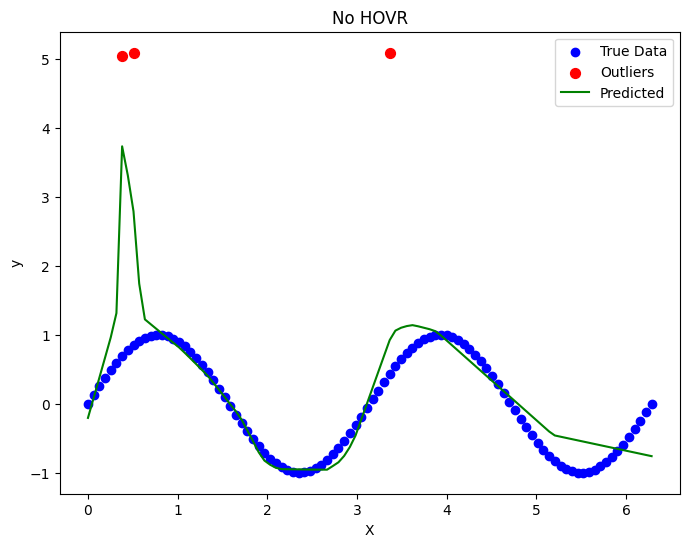

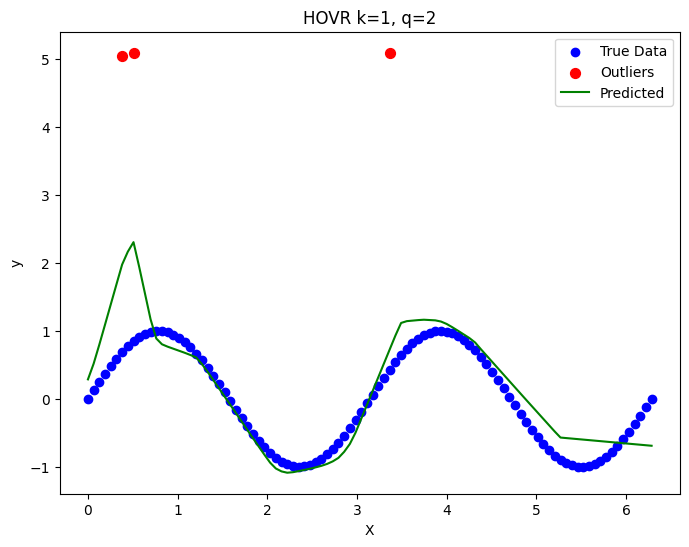

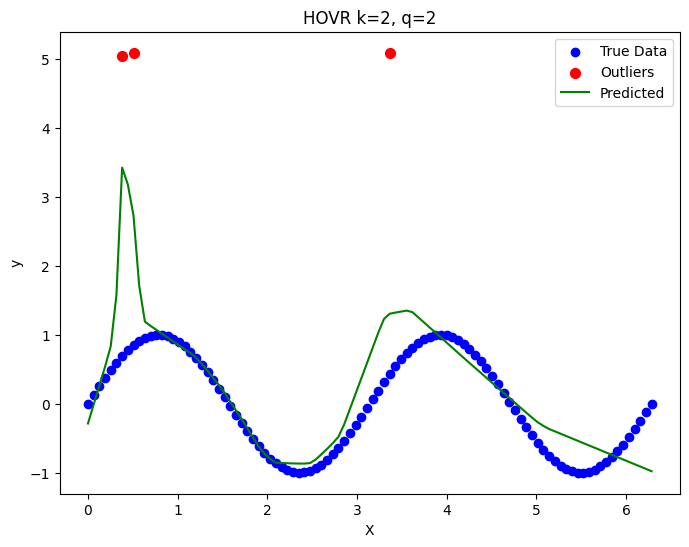

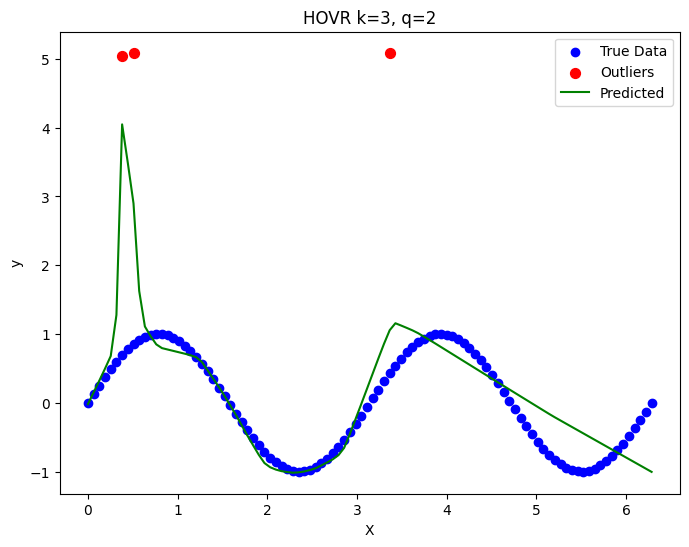

In [20]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1次元データセットの生成
def generate_data(n=100, noise_std=0.2, outlier_ratio=0.03):
    X = np.linspace(0, 2 * np.pi, n).reshape(-1, 1)
    y_true = np.sin(2 * X).flatten()
    y = y_true + np.random.normal(0, noise_std, X.shape[0])

    # 外れ値の挿入
    n_outliers = int(n * outlier_ratio)
    outlier_indices = np.random.choice(n, n_outliers, replace=False)
    y[outlier_indices] = 5 + np.random.uniform(-0.1, 0.1, n_outliers)

    return X, y, y_true, outlier_indices

# HOVR正則化の定義
def hovr_regularization(model, x, k=2, q=2, num_points=10):
    x_min, x_max = x.min(0)[0], x.max(0)[0]
    random_points = torch.tensor(np.random.uniform(x_min.numpy(), x_max.numpy(), (num_points, x.shape[1])), 
                                 dtype=torch.float32, requires_grad=True)
    preds = model(random_points)
    grads = torch.autograd.grad(preds, random_points, torch.ones_like(preds), create_graph=True)[0]

    hovr_term = 0.0
    for i in range(x.shape[1]):
        grad_i = grads[:, i]
        temp_grad = grad_i
        for _ in range(k - 1):
            temp_grad = torch.autograd.grad(temp_grad, random_points, torch.ones_like(temp_grad), create_graph=True)[0][:, i]
        hovr_term += torch.sum(torch.abs(temp_grad) ** q)
    
    return hovr_term / x.shape[1]

# モデルの訓練
def train_model(X, y, model, optimizer, hovr_lambda=None, hovr_k=None, hovr_q=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # HOVR正則化を追加
        if hovr_lambda is not None and hovr_k is not None and hovr_q is not None:
            hovr_term = hovr_regularization(model, X_tensor, k=hovr_k, q=hovr_q)
            loss += hovr_lambda * hovr_term

        loss.backward()
        optimizer.step()

# モデルの訓練
def train_special_model(X, y, model, optimizer, hovr_lambda=None, num_epochs=5000):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        preds = model(X_tensor)
        loss = nn.MSELoss()(preds, y_tensor)
        
        # hovr_term_1 = hovr_regularization(model, X_tensor, k=1, q=2)
        hovr_term_2 = hovr_regularization(model, X_tensor, k=2, q=2)
        hovr_term_3 = hovr_regularization(model, X_tensor, k=3, q=2)
        loss += 1e-3 * hovr_term_2
        loss += 1e-3 * hovr_term_3

        loss.backward()
        optimizer.step()

# 1次元データの予測結果をプロット
def plot_1d(X, y, predict_func, title, outlier_indices, y_true):
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y_true, color='blue', label='True Data')
    plt.scatter(X[outlier_indices], y[outlier_indices], color='red', label='Outliers', s=50)

    X_grid = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)
    y_grid_pred = predict_func(X_grid)

    plt.plot(X_grid, y_grid_pred, color='green', label='Predicted')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.show()

# 各モデルの訓練とプロット
def train_and_plot(X, y, y_true, outlier_indices, hovr_settings=None):
    model = MLP(input_dim=1, hidden_dim=128, output_dim=1)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    if hovr_settings is None:
        train_model(X, y, model, optimizer, num_epochs=100)
    else:
        hovr_lambda, hovr_k, hovr_q = hovr_settings
        train_model(X, y, model, optimizer, hovr_lambda=hovr_lambda, hovr_k=hovr_k, hovr_q=hovr_q, num_epochs=100)

    predict_func = lambda X_new: model(torch.tensor(X_new, dtype=torch.float32)).detach().numpy().flatten()
    title = f"HOVR k={hovr_k}, q={hovr_q}" if hovr_settings else "No HOVR"
    plot_1d(X, y, predict_func, title, outlier_indices, y_true)

# 使用例
if __name__ == "__main__":
    X, y, y_true, outlier_indices = generate_data()

    # 通常のモデル (HOVRなし)
    train_and_plot(X, y, y_true, outlier_indices)

    # (1, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 1, 2))

    # (2, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 2, 2))

    # (3, 2)-VR
    train_and_plot(X, y, y_true, outlier_indices, hovr_settings=(1e-3, 3, 2))
